# 🐾 Pet Store Business Analytics — 2020

**Dataset:** 879 product records from a global pet store supply chain  
**Columns:** product_id, product_category, sales, price, VAP (value-added product flag), vendor_id, country, pet_size, pet_type, rating, re_buy

---

## Table of Contents
1. [Setup & Data Loading](#1)
2. [KPI Summary](#2)
3. [Revenue Analysis](#3)
4. [Product & Pricing Analysis](#4)
5. [Customer Behaviour — Ratings & Re-buy](#5)
6. [Vendor & Country Intelligence](#6)
7. [Value-Added Products (VAP)](#7)
8. [Correlation & Feature Insights](#8)
9. [Key Business Recommendations](#9)

## 1. Setup & Data Loading <a id='1'></a>

In [6]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src') if 'notebooks' in os.getcwd() else 'src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [8]:
from src.analysis import (
    load_data, summary_stats, revenue_by_category, revenue_by_country,
    metrics_by_pet_type, vap_vs_standard, top_vendors, sales_heatmap_data,
    rating_distribution, rebuy_by_rating_bucket, correlation_matrix,
    price_tier_analysis
)
from src.visualizations import (
    plot_revenue_by_category, plot_revenue_by_country, plot_sales_heatmap,
    plot_rating_distribution, plot_vap_comparison, plot_rebuy_by_rating,
    plot_price_tier_analysis, plot_correlation_heatmap, plot_pet_type_bubble
)

# Load data (run from project root)
DATA_PATH = 'data/pet_store_records_2020.csv'
df = load_data(DATA_PATH)
print(f'Loaded {len(df):,} records with {df.shape[1]} columns')
df.head()


Loaded 879 records with 12 columns


,product_id,product_category,sales,price,is_value_added_product,vendor_id,country,pet_size,pet_type,rating,re_buy,revenue
0,5040,Equipment,123,7293,False,VC_1605,Vietnam,small,fish,7,True,897039
1,4567,Toys,61,9304,True,VC_1132,India,small,cat,10,False,567544
2,4237,Toys,218,8180,False,VC_802,India,small,hamster,6,False,1783240
3,4364,Snack,69,18559,True,VC_929,India,large,dog,1,True,1280571
4,4184,Supplements,138,10283,True,VC_749,India,large,dog,10,False,1419054


## 2. KPI Summary <a id='2'></a>

In [10]:
kpis = summary_stats(df)

print('=' * 50)
print('         PET STORE 2020 — KEY METRICS')
print('=' * 50)
print(f"  Total Records       : {kpis['total_records']:,}")
print(f"  Total Revenue       : ${kpis['total_revenue']:,.0f}")
print(f"  Avg Price per Unit  : ${kpis['avg_price']:,.0f}")
print(f"  Avg Units Sold      : {kpis['avg_sales']:.1f}")
print(f"  Avg Product Rating  : {kpis['avg_rating']:.2f}/10")
print(f"  Re-buy Rate         : {kpis['rebuy_rate_pct']:.1f}%")
print(f"  Value-Added Products: {kpis['vap_share_pct']:.1f}% of catalog")
print(f"  Unique Vendors      : {kpis['unique_vendors']}")
print(f"  Unique Products     : {kpis['unique_products']}")
print(f"  Countries           : {kpis['countries']}")
print('=' * 50)

         PET STORE 2020 — KEY METRICS
  Total Records       : 879
  Total Revenue       : $1,013,834,282
  Avg Price per Unit  : $9,862
  Avg Units Sold      : 116.1
  Avg Product Rating  : 6.50/10
  Re-buy Rate         : 46.6%
  Value-Added Products: 50.6% of catalog
  Unique Vendors      : 879
  Unique Products     : 879
  Countries           : 9


## 3. Revenue Analysis <a id='3'></a>

### 3a. Revenue by Product Category

In [ ]:
#%pip install Jinja2

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


,product_category,total_revenue,avg_price,total_units_sold,avg_rating,rebuy_rate
0,Snack,"$165,430,703","$9,765","16,399",5.94,43.3%
1,Equipment,"$163,393,635","$9,967","16,679",5.97,51.1%
2,Toys,"$152,795,153","$10,512","14,696",5.84,41.8%
3,Medicine,"$94,017,290","$10,304","9,154",7.07,51.3%
4,Supplements,"$81,234,360","$9,424","8,312",7.57,42.7%
5,Food,"$70,901,185","$9,342","7,999",7.63,49.3%
6,Accessory,"$67,274,018","$9,520","6,450",6.54,47.8%
7,Clothes,"$58,843,909","$10,092","5,687",7.30,47.8%
8,Bedding,"$55,086,886","$9,461","5,821",6.65,56.5%
9,Grooming,"$54,367,168","$9,227","5,832",6.17,43.5%


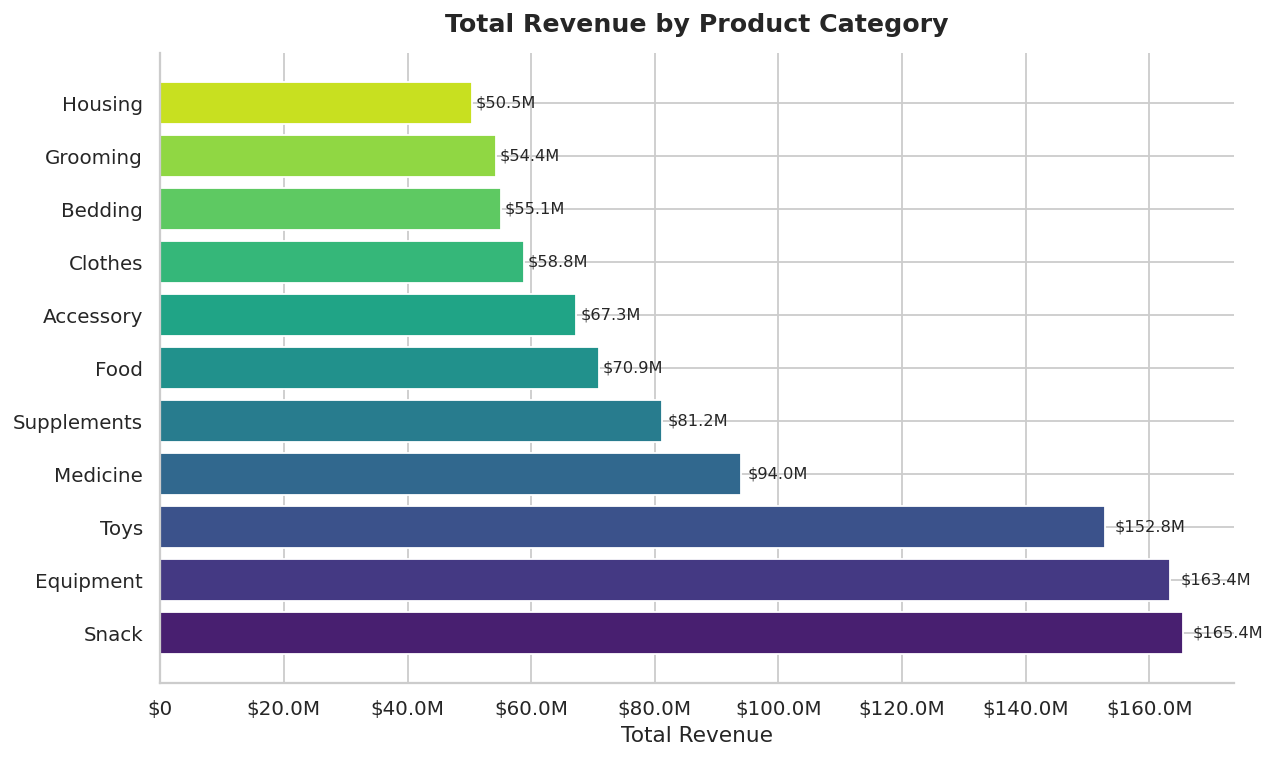

In [13]:
cat_rev = revenue_by_category(df)
display(cat_rev.style.format({
    'total_revenue': '${:,.0f}',
    'avg_price': '${:,.0f}',
    'total_units_sold': '{:,}',
    'avg_rating': '{:.2f}',
    'rebuy_rate': '{:.1%}',
}).background_gradient(subset=['total_revenue'], cmap='Blues'))

fig = plot_revenue_by_category(cat_rev)
plt.show()

### 3b. Revenue by Country

,country,total_revenue,avg_rating,num_products,rebuy_rate
0,India,"$589,285,676",6.83,513,48.1%
1,USA,"$84,956,325",6.04,69,42.0%
2,Singapore,"$81,092,591",5.97,70,42.9%
3,Germany,"$79,944,571",6.03,69,40.6%
4,Turkey,"$76,751,581",5.97,69,42.0%
5,Belgium,"$70,392,543",5.97,69,39.1%
6,Vietnam,"$17,592,903",6.90,10,100.0%
7,Sri Lanka,"$13,512,878",6.89,9,100.0%
8,Japan,"$305,214",6.00,1,100.0%


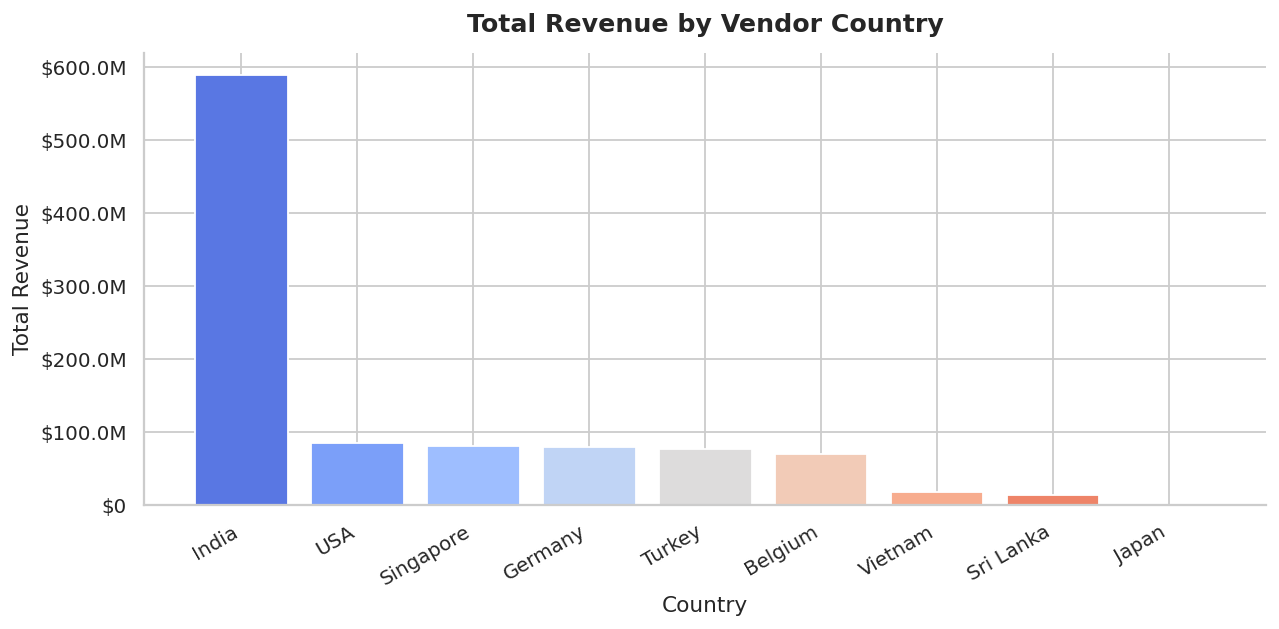

In [14]:
ctr_rev = revenue_by_country(df)
display(ctr_rev.style.format({
    'total_revenue': '${:,.0f}',
    'avg_rating': '{:.2f}',
    'rebuy_rate': '{:.1%}',
}).background_gradient(subset=['total_revenue'], cmap='Greens'))

fig = plot_revenue_by_country(ctr_rev)
plt.show()

### 3c. Sales Heatmap — Pet Type × Product Category

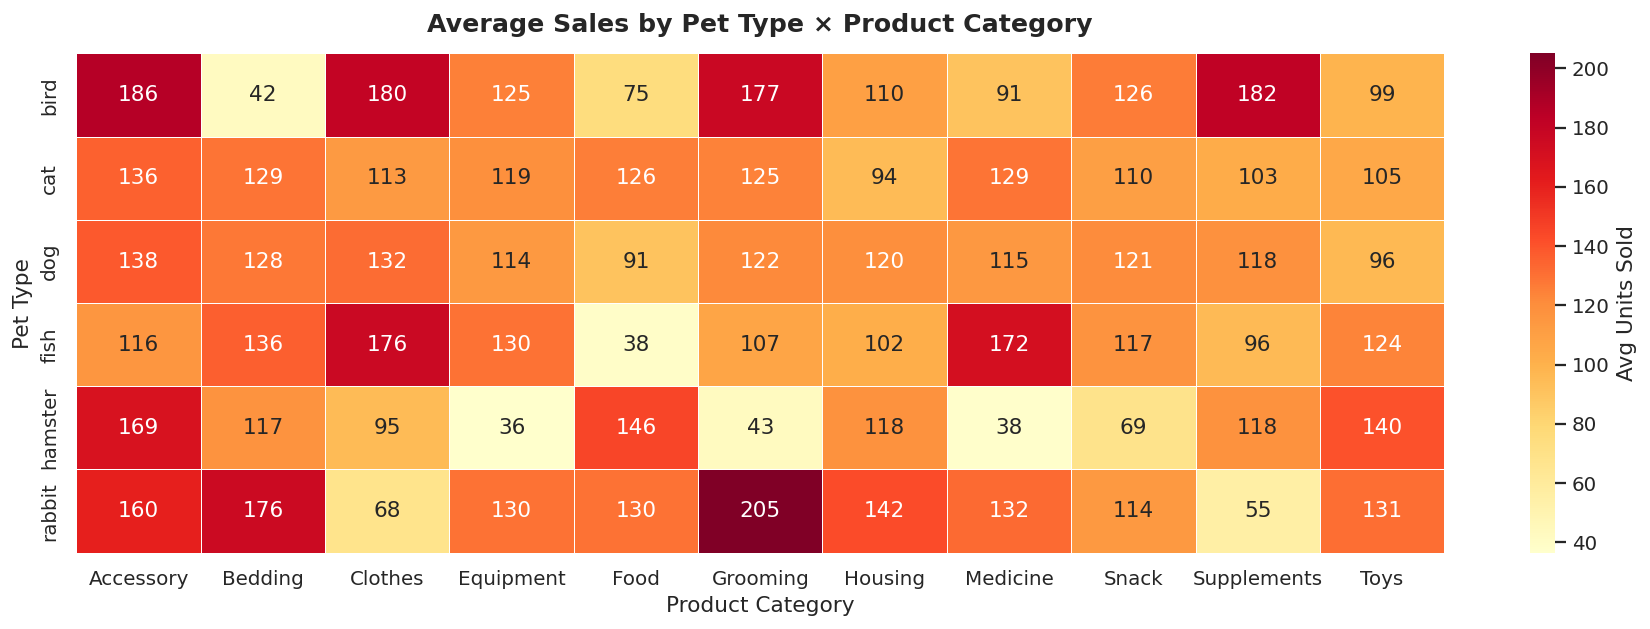


Top 3 highest-selling combinations:
  Rabbit × Grooming: 205 avg units/record
  Bird × Accessory: 186 avg units/record
  Bird × Supplements: 182 avg units/record


In [15]:
pivot = sales_heatmap_data(df)
fig = plot_sales_heatmap(pivot)
plt.show()
print('\nTop 3 highest-selling combinations:')
stacked = pivot.stack().sort_values(ascending=False).head(3)
for (pet, cat), val in stacked.items():
    print(f'  {pet.capitalize()} × {cat}: {val:.0f} avg units/record')

## 4. Product & Pricing Analysis <a id='4'></a>

Price Tier Breakdown:


,price_tier,avg_sales,avg_rating,rebuy_rate,count
0,Budget,119.2,6.50,42.3%,220
1,Economy,109.4,6.25,43.2%,220
2,Mid-range,114.6,6.35,49.8%,219
3,Premium,121.2,6.89,51.4%,220


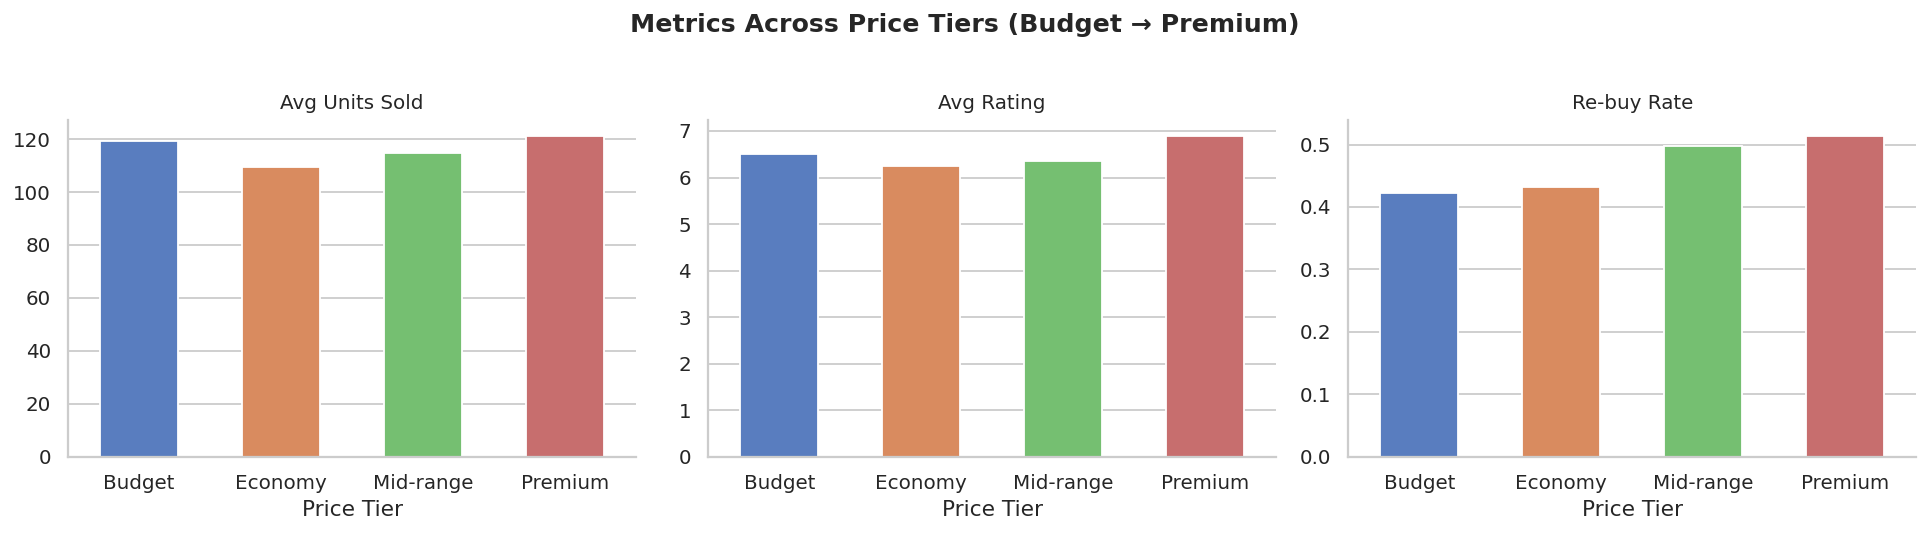

In [16]:
price_tiers = price_tier_analysis(df)
print('Price Tier Breakdown:')
display(price_tiers.style.format({
    'avg_sales': '{:.1f}',
    'avg_rating': '{:.2f}',
    'rebuy_rate': '{:.1%}',
    'count': '{:,}'
}))

fig = plot_price_tier_analysis(price_tiers)
plt.show()

,pet_type,total_revenue,avg_price,avg_sales,avg_rating,rebuy_rate
0,cat,"$396,230,488","$9,769",115.9,6.63,47.6%
1,dog,"$382,630,443","$9,787",114.4,6.64,49.0%
2,bird,"$90,347,101","$10,587",119.5,5.65,40.6%
3,fish,"$85,399,056","$9,787",122.0,6.33,38.6%
4,rabbit,"$35,136,827","$10,639",134.3,6.09,47.8%
5,hamster,"$24,090,367","$9,692",97.6,5.83,39.1%


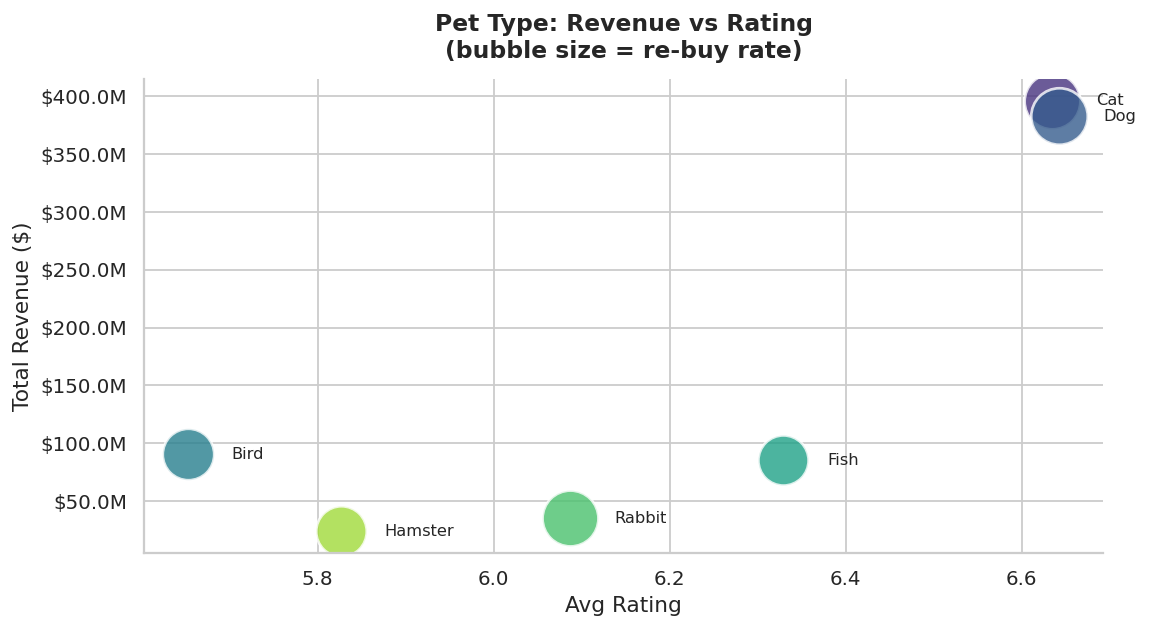

In [17]:
# Pet type performance bubble chart
pet_metrics = metrics_by_pet_type(df)
display(pet_metrics.style.format({
    'total_revenue': '${:,.0f}',
    'avg_price': '${:,.0f}',
    'avg_sales': '{:.1f}',
    'avg_rating': '{:.2f}',
    'rebuy_rate': '{:.1%}',
}))

fig = plot_pet_type_bubble(pet_metrics)
plt.show()

## 5. Customer Behaviour — Ratings & Re-buy <a id='5'></a>

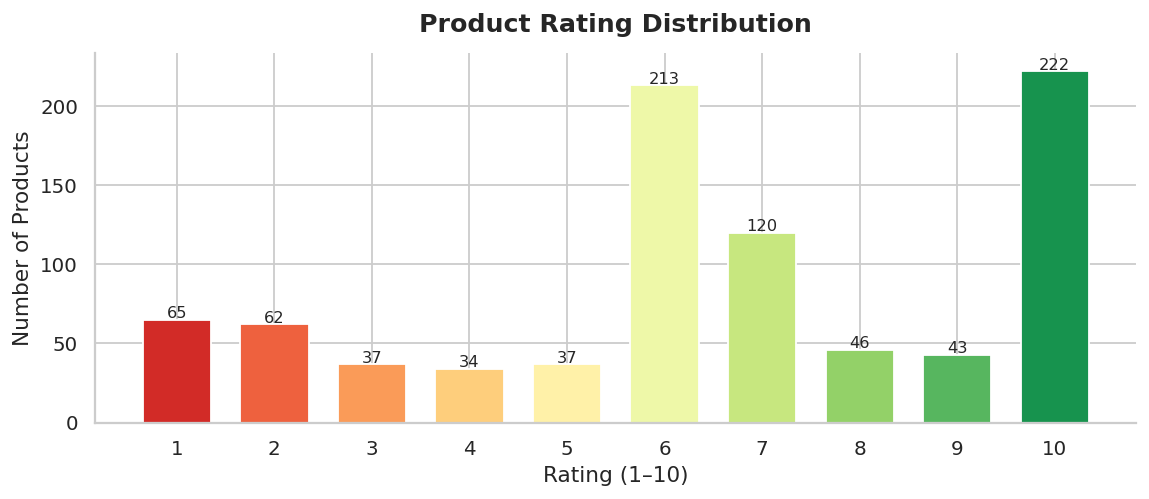


Median rating : 6.0
% rated 8+ : 35.4%
% rated 3 or below: 18.7%


In [18]:
rating_dist = rating_distribution(df)
fig = plot_rating_distribution(rating_dist)
plt.show()

print(f"\nMedian rating : {df['rating'].median()}")
print(f"% rated 8+ : {(df['rating'] >= 8).mean()*100:.1f}%")
print(f"% rated 3 or below: {(df['rating'] <= 3).mean()*100:.1f}%")

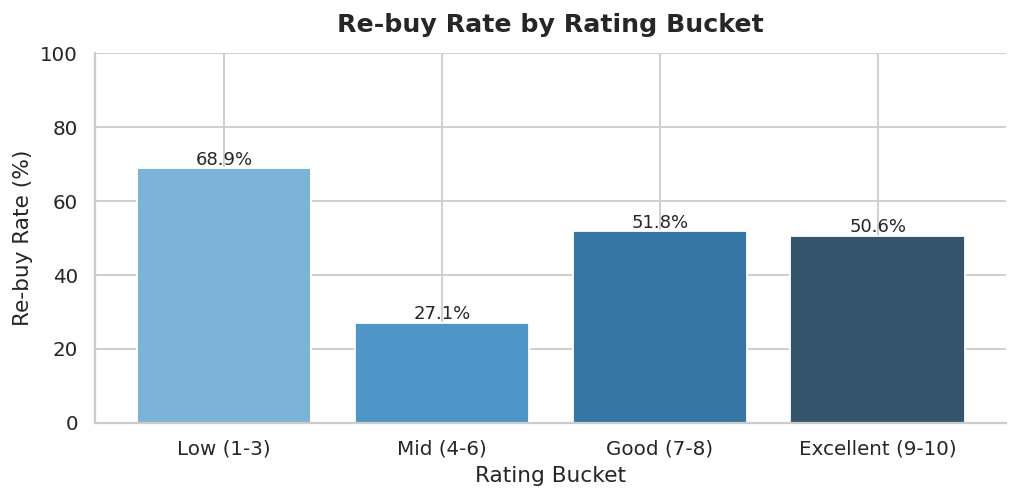


Re-buy rate by rating bucket:


,rating_bucket,rebuy_rate_pct
0,Low (1-3),68.9%
1,Mid (4-6),27.1%
2,Good (7-8),51.8%
3,Excellent (9-10),50.6%


In [19]:
rebuy_bucket = rebuy_by_rating_bucket(df)
fig = plot_rebuy_by_rating(rebuy_bucket)
plt.show()

print('\nRe-buy rate by rating bucket:')
display(rebuy_bucket.style.format({'rebuy_rate_pct': '{:.1f}%'}))

## 6. Vendor & Country Intelligence <a id='6'></a>

Top 10 Vendors by Revenue:


,vendor_id,total_revenue,avg_rating,product_count
0,VC_1368,"$4,244,054",7.00,1
1,VC_991,"$4,233,960",8.00,1
2,VC_1107,"$4,211,578",10.00,1
3,VC_831,"$4,160,576",5.00,1
4,VC_1424,"$4,063,840",1.00,1
5,VC_1587,"$4,053,864",6.00,1
6,VC_1401,"$4,053,777",2.00,1
7,VC_861,"$3,989,050",8.00,1
8,VC_1551,"$3,984,300",6.00,1
9,VC_1608,"$3,973,338",7.00,1


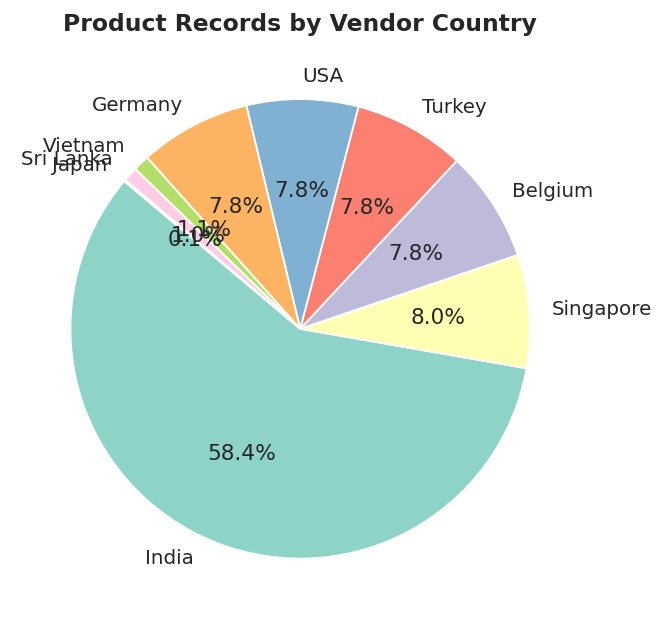

In [20]:
vendors = top_vendors(df, n=10)
print('Top 10 Vendors by Revenue:')
display(vendors.style.format({
    'total_revenue': '${:,.0f}',
    'avg_rating': '{:.2f}',
}).background_gradient(subset=['total_revenue'], cmap='Purples'))

# Country distribution pie
fig, ax = plt.subplots(figsize=(8, 5))
country_counts = df['country'].value_counts()
wedges, texts, autotexts = ax.pie(
    country_counts,
    labels=country_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set3', len(country_counts)),
    startangle=140,
)
ax.set_title('Product Records by Vendor Country', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Value-Added Products (VAP) <a id='7'></a>

,is_value_added_product,count,avg_price,avg_sales,avg_rating,rebuy_rate,avg_revenue
0,False,434,"$9,504",115.3,6.39,44.2%,"$1,071,926"
1,True,445,"$10,212",116.8,6.61,49.0%,"$1,232,850"


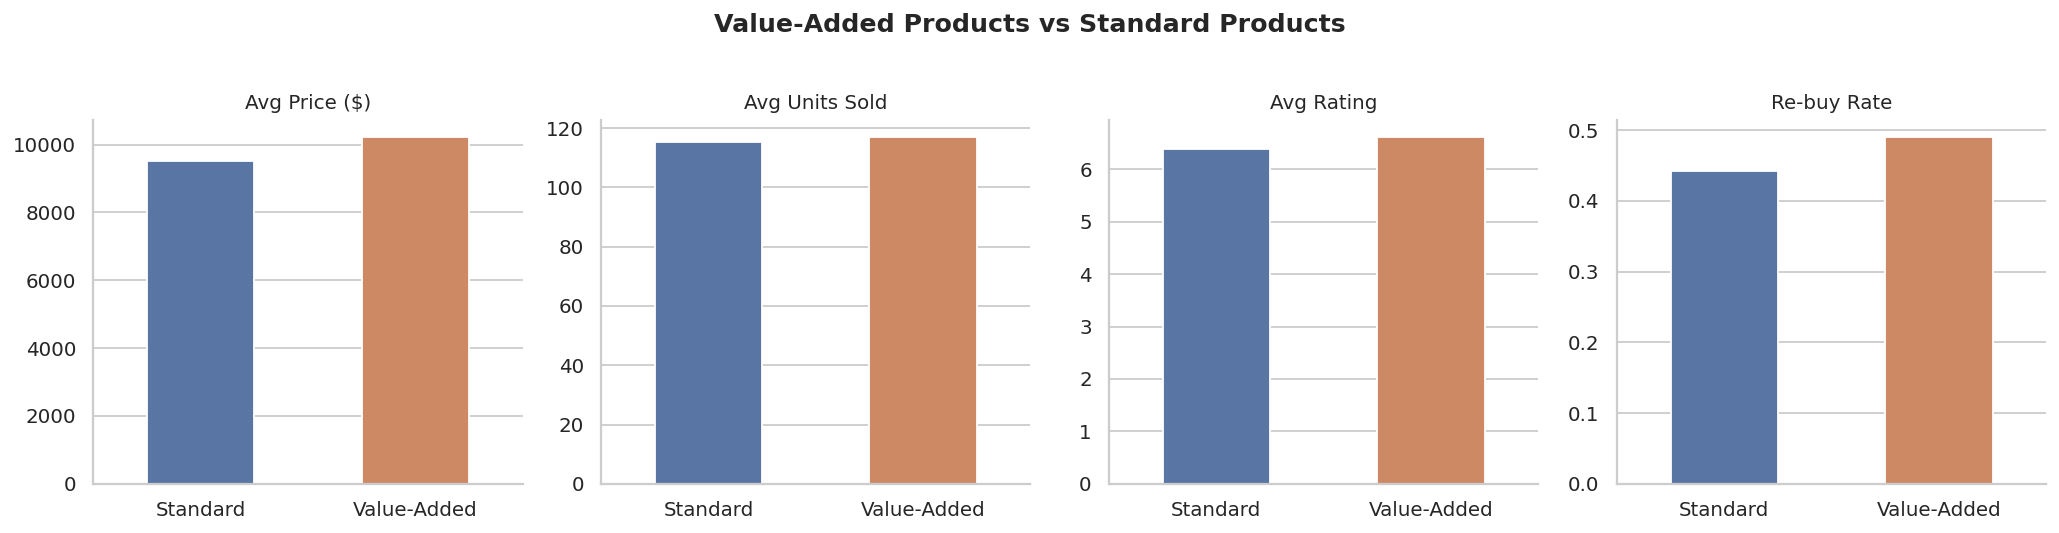

In [21]:
vap_data = vap_vs_standard(df)
display(vap_data.style.format({
    'avg_price': '${:,.0f}',
    'avg_revenue': '${:,.0f}',
    'avg_sales': '{:.1f}',
    'avg_rating': '{:.2f}',
    'rebuy_rate': '{:.1%}',
}))

fig = plot_vap_comparison(vap_data)
plt.show()

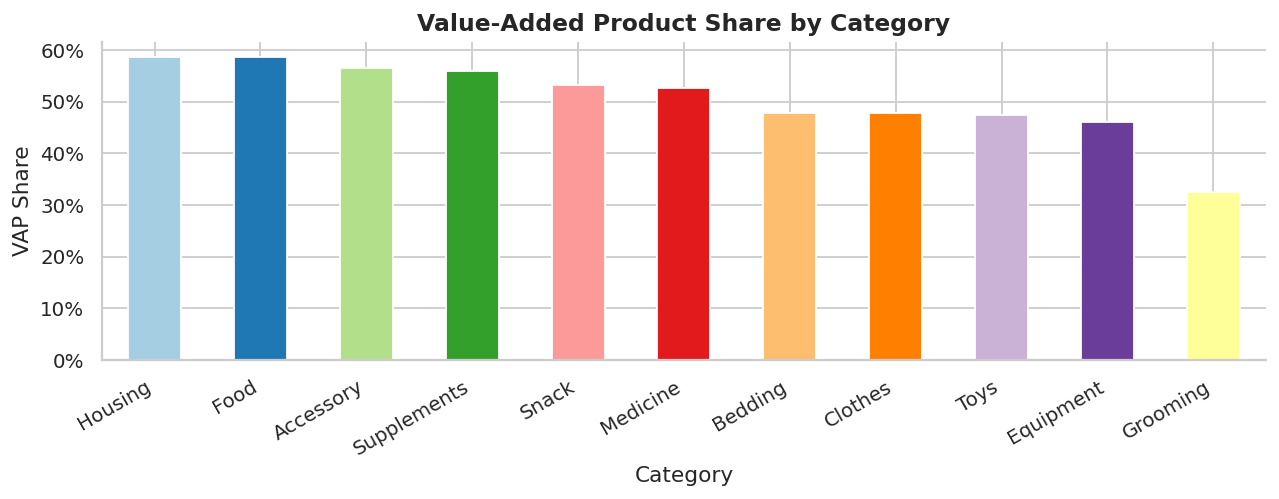

In [22]:
# VAP share per category
vap_cat = df.groupby('product_category')['is_value_added_product'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
vap_cat.plot(kind='bar', ax=ax, color=sns.color_palette('Paired', len(vap_cat)), edgecolor='white')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylabel('VAP Share')
ax.set_xlabel('Category')
ax.set_title('Value-Added Product Share by Category', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 8. Correlation & Feature Insights <a id='8'></a>

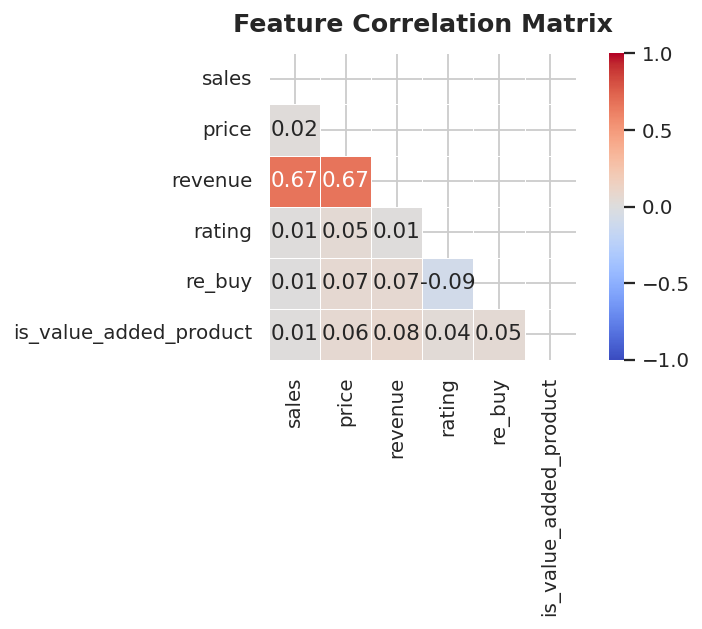


Key correlations with re_buy:
price                     0.069
revenue                   0.068
is_value_added_product    0.048
sales                     0.006
rating                   -0.087


In [23]:
corr = correlation_matrix(df)
fig = plot_correlation_heatmap(corr)
plt.show()

print('\nKey correlations with re_buy:')
print(corr['re_buy'].sort_values(ascending=False).drop('re_buy').to_string())

## 9. Key Business Recommendations <a id='9'></a>

Based on the analysis above:

| # | Insight | Recommendation |
|---|---------|----------------|
| 1 | **Top revenue categories** dominate the catalog | Prioritise restocking and marketing budget toward top-performing categories |
| 2 | **VAP products** command higher prices | Expand value-added product lines — higher margin, similar sales volume |
| 3 | **Re-buy rate is ~47%** — nearly half of customers return | Implement a loyalty programme to convert one-time buyers |
| 4 | **Rating & re-buy are loosely correlated** | Focus on post-purchase quality to push ratings from 6→8+ where re-buy jumps |
| 5 | **India dominates vendor share** | Diversify supplier base to reduce geographic concentration risk |
| 6 | **Premium-tier products don't always sell more** | Bundle premium products with mid-range accessories to drive attach rate |
| 7 | **Dog products lead revenue** | Dog category warrants dedicated marketing campaigns and SKU expansion |